В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [112]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [113]:
df = pd.read_csv('drive/MyDrive/cars.csv')

In [114]:
df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [116]:
df.select_dtypes('object').columns.to_list()

['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Owner_Type']

In [117]:
df[['Fuel_Type', 'Transmission', 'Owner_Type']].value_counts()

Fuel_Type  Transmission  Owner_Type
Petrol     Automatic     Second        19
Diesel     Automatic     First         16
                         Second        13
           Manual        First         11
Petrol     Manual        First         10
                         Third         10
Diesel     Manual        Second         7
Petrol     Automatic     First          7
           Manual        Second         4
           Automatic     Third          2
Diesel     Manual        Third          1
Name: count, dtype: int64

**ОПИС КОЛОНОК**

У ноборі даних `cars.csv` всього 13 колонок

8 числових (тип даних кожної `integer`).

5 категоріальних:
* кожна колонка має по 100 спостережень та тип даних `string`.
* 2 бінарні `Fuel_Type` та `Transmission`
* 3 мультикатегоріальні: 2 номінальні (`Brand`,`Model`), порядкова (`Owner_Type`)

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [118]:
from sklearn.model_selection import train_test_split

In [119]:
df.columns.to_list()

['Car_ID',
 'Brand',
 'Model',
 'Year',
 'Kilometers_Driven',
 'Fuel_Type',
 'Transmission',
 'Owner_Type',
 'Mileage',
 'Engine',
 'Power',
 'Seats',
 'Price']

In [120]:
x_fact, y_fact = df[['Car_ID','Brand','Model','Year','Kilometers_Driven','Fuel_Type','Transmission','Owner_Type','Mileage','Engine','Power','Seats']], df['Price']

In [121]:
X_train, X_test, y_train, y_test = train_test_split(x_fact, y_fact, test_size=0.2, random_state=12)

**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

***Кодування бінарних колонок***

In [122]:
df.Fuel_Type.value_counts()

,count
Fuel_Type,
Petrol,52
Diesel,48


In [123]:
df.Transmission.value_counts()

,count
Transmission,
Automatic,57
Manual,43


In [124]:
fuel_type_codes = {'Petrol': 1, 'Diesel': 0}
transmission_codes = {'Automatic': 1,'Manual': 0}

In [125]:
X_train['Fuel_Type_code'] = X_train.Fuel_Type.map(fuel_type_codes)
X_train['Transmission_code'] = X_train.Transmission.map(transmission_codes)

In [126]:
X_test['Fuel_Type_code'] = X_test.Fuel_Type.map(fuel_type_codes)
X_test['Transmission_code'] = X_test.Transmission.map(transmission_codes)

***Кодування номінальних колонок***

*`Brand`*

In [127]:
df.Brand.unique()

array(['Toyota', 'Honda', 'Ford', 'Maruti', 'Hyundai', 'Tata', 'Mahindra',
       'Volkswagen', 'Audi', 'BMW', 'Mercedes'], dtype=object)

In [128]:
from sklearn import preprocessing

brand_enc = preprocessing.OneHotEncoder(handle_unknown='ignore') # створення окремою змінною кодувальник (якщо в тесті буде бренд, якого немає в тренувальному, не видавати помилку)
brand_enc.fit(X_train[['Brand']]) # "навчання" - розпізнання унікальних категорій в колонці тренувального набору та правил майбутнього кодування через fit()
brand_enc.categories_

[array(['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti',
        'Mercedes', 'Tata', 'Toyota', 'Volkswagen'], dtype=object)]

In [129]:
brand_train_one_hot = brand_enc.transform(X_train[['Brand']]).toarray() # безпосереднє кодування значень колонки через transform() в трен. наборі без зміни набору наразі
brand_test_one_hot = brand_enc.transform(X_test[['Brand']]).toarray()

In [130]:
# створення назв колонок за категоріями, які будуть введені в набір даних ([0] озн., що кодуємо перший масив категорій (кодувальник може декілька), який єдиний - 'Brand')
brand_columns = brand_enc.categories_[0]

In [131]:
# додавання нових колонок (кожна відповідає за певну категорію бренду) до наборів із закодованими значеннями
X_train[brand_columns] = brand_train_one_hot
X_test[brand_columns] = brand_test_one_hot

*`Model`*

In [132]:
df.Model.unique()

array(['Corolla', 'Civic', 'Mustang', 'Swift', 'Sonata', 'Nexon',
       'Scorpio', 'Polo', 'A4', 'X1', 'C-Class', 'Endeavour', 'Creta',
       'Harrier', 'Ertiga', 'City', 'Tiguan', 'Q3', '5 Series', 'GLC',
       'Innova', 'Figo', 'Verna', 'Altroz', 'Thar', 'Passat', 'A6', 'X3',
       'E-Class', 'Fortuner', 'Aspire', 'Elantra', 'Safari', 'Vitara',
       'WR-V', 'Ameo', 'A3', '7 Series', 'GLE', 'Yaris', 'Ranger',
       'Santro', 'Tigor', 'S-Cross', 'BR-V', 'T-Roc', 'Q7', 'X5', 'GLA',
       'Camry', 'Venue', 'Tiago', 'XUV300', 'Vento', 'A5', '3 Series',
       'Innova Crysta', 'EcoSport'], dtype=object)

In [133]:
#групування моделей авто за типом кузова

car_body = {
    # Sedan / Coupe
    'Corolla': 'Sedan_Coupe',
    'Civic': 'Sedan_Coupe',
    'Mustang': 'Sedan_Coupe',
    'Sonata': 'Sedan_Coupe',
    'A4': 'Sedan_Coupe',
    'C-Class': 'Sedan_Coupe',
    'City': 'Sedan_Coupe',
    '5 Series': 'Sedan_Coupe',
    'Verna': 'Sedan_Coupe',
    'Passat': 'Sedan_Coupe',
    'A6': 'Sedan_Coupe',
    'E-Class': 'Sedan_Coupe',
    'Aspire': 'Sedan_Coupe',
    'Elantra': 'Sedan_Coupe',
    'Ameo': 'Sedan_Coupe',
    'A3': 'Sedan_Coupe',
    '7 Series': 'Sedan_Coupe',
    'Yaris': 'Sedan_Coupe',
    'Tigor': 'Sedan_Coupe',
    'Camry': 'Sedan_Coupe',
    'Vento': 'Sedan_Coupe',
    'A5': 'Sedan_Coupe',
    '3 Series': 'Sedan_Coupe',

    # Hatchback
    'Swift': 'Hatchback',
    'Polo': 'Hatchback',
    'Figo': 'Hatchback',
    'Altroz': 'Hatchback',
    'Santro': 'Hatchback',
    'Tiago': 'Hatchback',

    # SUV / Crossover
    'Nexon': 'SUV_Crossover',
    'Scorpio': 'SUV_Crossover',
    'X1': 'SUV_Crossover',
    'Endeavour': 'SUV_Crossover',
    'Creta': 'SUV_Crossover',
    'Harrier': 'SUV_Crossover',
    'Tiguan': 'SUV_Crossover',
    'Q3': 'SUV_Crossover',
    'GLC': 'SUV_Crossover',
    'X3': 'SUV_Crossover',
    'Thar': 'SUV_Crossover',
    'Fortuner': 'SUV_Crossover',
    'Safari': 'SUV_Crossover',
    'Vitara': 'SUV_Crossover',
    'WR-V': 'SUV_Crossover',
    'S-Cross': 'SUV_Crossover',
    'BR-V': 'SUV_Crossover',
    'T-Roc': 'SUV_Crossover',
    'Q7': 'SUV_Crossover',
    'X5': 'SUV_Crossover',
    'GLA': 'SUV_Crossover',
    'GLE': 'SUV_Crossover',
    'Venue': 'SUV_Crossover',
    'XUV300': 'SUV_Crossover',
    'EcoSport': 'SUV_Crossover',

    # MPV
    'Ertiga': 'MPV',
    'Innova': 'MPV',
    'Innova Crysta': 'MPV',

    # Pickup
    'Ranger': 'Pickup'
}

In [134]:
X_train['Car_Body'] = X_train.Model.map(car_body).fillna('Other')
X_test['Car_Body'] = X_test.Model.map(car_body).fillna('Other')

In [135]:
model_enc = preprocessing.OneHotEncoder(handle_unknown='ignore')
model_enc.fit(X_train[['Car_Body']])
model_enc.categories_

[array(['Hatchback', 'MPV', 'Pickup', 'SUV_Crossover', 'Sedan_Coupe'],
       dtype=object)]

In [136]:
model_train_one_hot = model_enc.transform(X_train[['Car_Body']]).toarray()
model_test_one_hot = model_enc.transform(X_test[['Car_Body']]).toarray()

In [137]:
model_columns = model_enc.categories_[0]

In [138]:
X_train[model_columns] = model_train_one_hot
X_test[model_columns] = model_test_one_hot

***Кодування порядкових колонок***

In [139]:
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

Очікуваний результат після трансформацій:

In [140]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_code,Transmission_code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Car_Body,Hatchback,MPV,Pickup,SUV_Crossover,Sedan_Coupe,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,SUV_Crossover,0.0,0.0,0.0,1.0,0.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sedan_Coupe,0.0,0.0,0.0,0.0,1.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sedan_Coupe,0.0,0.0,0.0,0.0,1.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Sedan_Coupe,0.0,0.0,0.0,0.0,1.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,SUV_Crossover,0.0,0.0,0.0,1.0,0.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_code,Transmission_code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Car_Body,Hatchback,MPV,Pickup,SUV_Crossover,Sedan_Coupe,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SUV_Crossover,0.0,0.0,0.0,1.0,0.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Hatchback,1.0,0.0,0.0,0.0,0.0,2.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Sedan_Coupe,0.0,0.0,0.0,0.0,1.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,MPV,0.0,1.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sedan_Coupe,0.0,0.0,0.0,0.0,1.0,2.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

*Видалення категоріальних колонок*

In [141]:
category_cols = X_train.select_dtypes(include = 'object').columns
category_cols

Index(['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Owner_Type',
       'Car_Body'],
      dtype='object')

In [142]:
try:
  X_train = X_train.drop(columns=category_cols)
except: KeyError

In [143]:
try:
  X_test = X_test.drop(columns=category_cols)
except: KeyError

In [144]:
display(X_train.head()), display(X_test.head())

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_code,Transmission_code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Hatchback,MPV,Pickup,SUV_Crossover,Sedan_Coupe,Owner_Type_Codes
83,84,2019,22000,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
55,56,2018,28000,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
26,27,2018,28000,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
54,55,2017,32000,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
19,20,2017,26000,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_code,Transmission_code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Hatchback,MPV,Pickup,SUV_Crossover,Sedan_Coupe,Owner_Type_Codes
17,18,2016,38000,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
41,42,2019,26000,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0
92,93,2017,32000,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
14,15,2020,18000,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
68,69,2019,26000,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0


(None, None)

In [145]:
X_train.columns.equals(X_test.columns)

True

*Обʼєднання X та Y **тренувальних** наборів*

In [146]:
train_df = pd.concat([X_train, y_train], axis=1) # axis=1 - датафрейми додаються за горизонталлю (axis=0 - за вертикаллю)

In [147]:
train_df.head()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_code,Transmission_code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Hatchback,MPV,Pickup,SUV_Crossover,Sedan_Coupe,Owner_Type_Codes,Price
83,84,2019,22000,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1600000
55,56,2018,28000,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2600000
26,27,2018,28000,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3200000
54,55,2017,32000,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,650000
19,20,2017,26000,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2500000


*Кореляційна матриця*

In [148]:
corr_train = train_df.corr()
corr_train

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_code,Transmission_code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Hatchback,MPV,Pickup,SUV_Crossover,Sedan_Coupe,Owner_Type_Codes,Price
Car_ID,1.000000,0.137027,-0.356614,0.100891,-0.089284,-0.006319,-0.063793,0.090537,-0.084381,0.089473,0.048335,-0.020240,-0.050809,0.016831,0.006797,-0.054463,-0.045431,-0.032926,0.011350,0.020129,0.065514,0.033068,0.038733,-0.020088,-0.039866,0.038923,0.025560
Year,0.137027,1.000000,-0.708525,0.278559,-0.392764,-0.248442,-0.278755,0.248515,-0.200603,-0.256523,0.202517,-0.150454,-0.037437,-0.092099,0.181669,0.285094,-0.115157,0.248715,-0.219346,0.018255,0.412966,-0.123230,-0.194667,0.023506,-0.158052,-0.014499,-0.233769
Kilometers_Driven,-0.356614,-0.708525,1.000000,-0.126621,0.101219,-0.060803,0.403656,-0.332351,-0.066491,0.095879,-0.247042,-0.009761,0.057372,0.154362,-0.040344,-0.190420,-0.091731,0.030399,0.368519,-0.137675,-0.253460,0.273077,0.168300,-0.058048,0.062886,-0.001772,-0.083951
Mileage,0.100891,0.278559,-0.126621,1.000000,-0.710516,-0.684705,-0.178619,-0.070112,-0.399164,-0.152701,-0.134105,-0.296480,0.358630,0.217406,0.029427,0.116389,-0.238489,0.347678,-0.201565,0.085114,0.383419,-0.190723,-0.237671,-0.097244,0.012892,0.026624,-0.638404
Engine,-0.089284,-0.392764,0.101219,-0.710516,1.000000,0.801638,0.167326,-0.174455,0.456296,0.085153,0.287119,0.184231,-0.154491,-0.182213,-0.024973,-0.193257,0.163871,-0.340051,0.234889,-0.165115,-0.339919,0.205859,0.070044,0.084818,0.022552,-0.196106,0.710561
Power,-0.006319,-0.248442,-0.060803,-0.684705,0.801638,1.000000,-0.139388,0.076357,0.586910,0.157050,0.372652,0.240501,-0.191810,-0.170966,-0.118021,-0.220984,0.280827,-0.316989,-0.040478,-0.148437,-0.327726,0.008088,-0.017478,0.004900,0.184240,-0.204309,0.849137
Seats,-0.063793,-0.278755,0.403656,-0.178619,0.167326,-0.139388,1.000000,-0.412468,-0.070099,0.123674,-0.108079,-0.161451,0.200303,-0.086439,0.007738,-0.078379,-0.108079,-0.012748,0.348535,-0.094002,-0.094002,0.383470,-0.048609,0.328019,-0.376280,-0.043849,0.000979
Fuel_Type_code,0.090537,0.248515,-0.332351,-0.070112,-0.174455,0.076357,-0.412468,1.000000,-0.005775,-0.008336,-0.048475,0.109812,-0.161425,-0.007121,-0.235225,0.148511,-0.048475,0.066164,-0.008336,0.125010,0.213512,-0.164183,-0.164183,-0.097154,0.077915,0.281122,-0.110782
Transmission_code,-0.084381,-0.200603,-0.066491,-0.399164,0.456296,0.586910,-0.070099,-0.005775,1.000000,0.265132,0.283188,-0.122816,-0.218620,0.031659,-0.170703,-0.112622,0.283188,-0.397609,-0.076974,0.155500,-0.389318,-0.201319,-0.201319,-0.063196,0.410016,0.005886,0.680731
Audi,0.089473,-0.256523,0.095879,-0.152701,0.085153,0.157050,0.123674,-0.008336,0.265132,1.000000,-0.118678,-0.118678,-0.086066,-0.094916,-0.076472,-0.086066,-0.118678,-0.125988,-0.111111,-0.103221,-0.103221,-0.053376,-0.053376,-0.110031,0.201008,-0.203925,0.328858


<function matplotlib.pyplot.show(close=None, block=None)>

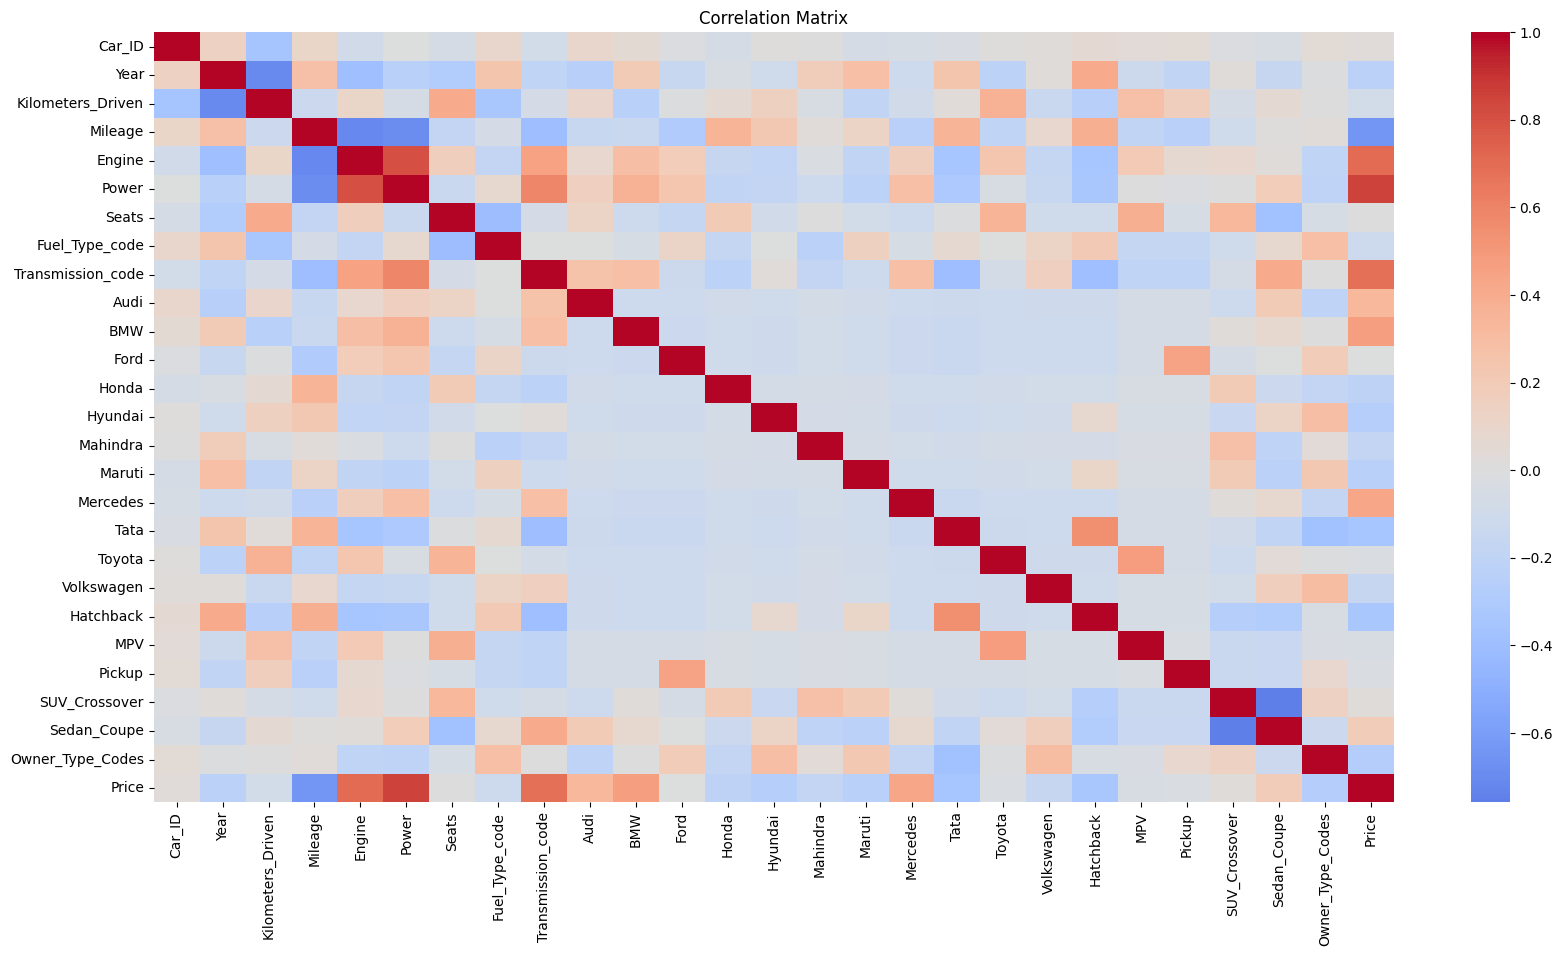

In [149]:
plt.figure(figsize=(20,10))
sns.heatmap(
    corr_train,
    cmap='coolwarm',
    center=0)
plt.title('Correlation Matrix')
plt.show


In [150]:
corr_price = corr_train['Price'].sort_values(ascending=True)
corr_price

,Price
Mileage,-0.638404
Tata,-0.341815
Hatchback,-0.338450
Owner_Type_Codes,-0.265537
Hyundai,-0.263022
Maruti,-0.249737
Year,-0.233769
Honda,-0.209779
Mahindra,-0.178627
Volkswagen,-0.158742


In [151]:
corr_price[(corr_price > 0.5) | (corr_price < -0.5)].sort_values(ascending=False)

,Price
Price,1.000000
Power,0.849137
Engine,0.710561
Transmission_code,0.680731
Mileage,-0.638404


**ВИСНОВОК**

Відповідно до матриці кореляції між залежною змінною `Price` та незалежними змінними, найбільш суттєва залежність (понад 0.5 за модулем) мають наступні змінні:
- висока кореляція: `Power` (0.85) та `Engine` (0.71)
- середня кореляція: `Transmission_code` (0.68) та `Mileage` (-0.64)

Наведені змінні з високим значенням кореляції демонструють обидві прямо пропорційний вплив на цільову змінну. Натомість змінні з середньою кореляцією різняться за характером впливу: `Transmission_code` з прямо пропорційним впливом, а `Mileage` - з обернено пропорційним.

Загальна кореляційна матриця також свідчить, що закодовані змінні брендів `Mercedes` та `BMW` демонструють наближену до порогового значення 0.5 (-0.5) в контексті значення кореляції, що становить 0.43 та 0.48 відповідно.
Наступним брендом за кореляцією йде `Tata` (-0.34) та `Audi` (0.32). Інші не перевищують 0.30 за модулем, що свідчить про низьку кореляцію з цільовою змінною.

Закодовані моделі під тип кузова також мають низькі кореляції. Найвищий показник має `Hatchback` (-0.33).

`Car_ID` є колонкою індексів, тому очікувано має низьку кореляцію з ціллю.

`Owner_Type_Codes` демонструє -0.26 значення, тобто низький обернено пропорційний вплив на `Price`.

Інші змінні близькі до 0 за значенням кореляції.

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [152]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

# тренування моделі
model = LinearRegression().fit(X_train, y_train) # визначення ознак і характеристик трен. даних та розрахунок коефіцієнтів моделі через fit()

# розрахунок прогнозів
y_train_pred = model.predict(X_train)
# розрахунок прогнозів на основі навченої моделі та знайдених коеф. за допомогою ТРЕНУВАЛЬНИХ даних (прогнози тесту розраховані без y_test саме для того, щоб оцінити потім помилку з фактичними даними та оцінити роботу моделі)
y_test_pred = model.predict(X_test)

# розрахунок середньоквадратичної помилки (RSME) - оцінка помилки між фактичними даними та прогнозами тесту / трен., змодельовані на основі тренувального набору
rsme_train = root_mean_squared_error(y_train, y_train_pred)
rsme_test = root_mean_squared_error(y_test, y_test_pred)

print('RMSE Training:', rsme_train)
print('RMSE Test:', rsme_test)

RMSE Training: 191188.2615303095
RMSE Test: 315186.7247166122


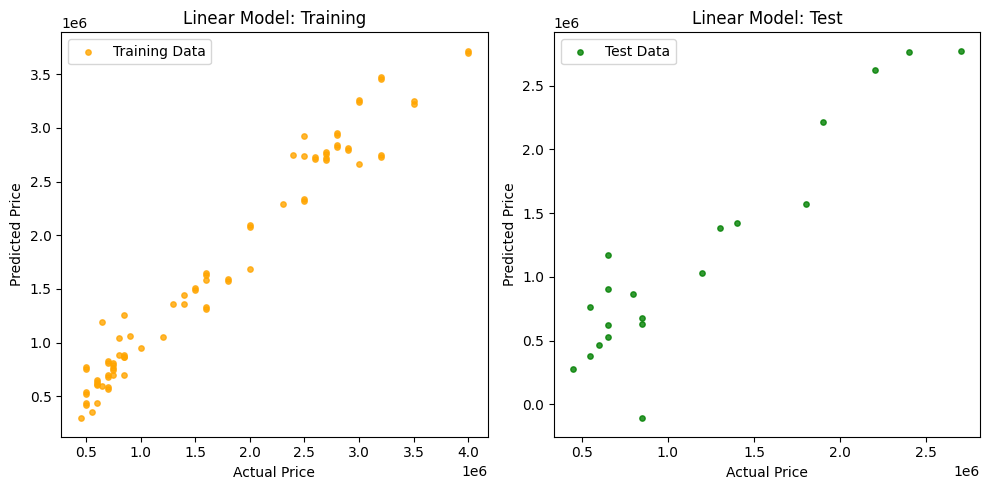

In [153]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.scatter(y_train, y_train_pred, c='orange', s=15, alpha=0.8, label='Training Data')
ax1.set_title('Linear Model: Training')
ax1.set_xlabel('Actual Price')
ax1.set_ylabel('Predicted Price')
ax1.legend()

ax2.scatter(y_test, y_test_pred, c='green', s=15, alpha=0.8, label='Test Data')
ax2.set_title('Linear Model: Test')
ax2.set_xlabel('Actual Price')
ax2.set_ylabel('Predicted Price')
ax2.legend()

plt.tight_layout()
plt.show()

**ВИСНОВОК**

Відповідно до значення RSME, різниця між фактичними та прогнозованими значеннями `Price` на тестувальному наборі в ~ 1.6 разів вища за цю різницю на тренувальних даних. Іншими словами, на тренувальному наборі прогноз моделі в середньому відхиляється від фактичної ціни приблизно на 191 тис., а на тестовому - приблизно на 315 тис. індійських рупій.
Тобто модель краще описує дані, на яких навчалася, і гірше працює з новими спостереженнями. Як висновок, значне зростання помилки.

Графік розсіювання в цілому підтверджує значно більший розкид даних на тесті, ніж на тренувальних даних. На тестовому наборі відхилення більші, хоча за рахунок незначної тестової вибірки однозначний висновок зробити важко.

Також присутній окремий суттєво помилковий прогноз із від’ємним значенням ціни. Водночас на тестових даних зберігається загальна позитивна залежність між фактичними та прогнозованими цінами, тому модель виявила основну закономірність, але потребує покращення для точнішого прогнозування нових даних.

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

***Масштабування***

In [154]:
from sklearn.preprocessing import StandardScaler

In [155]:
scaler = StandardScaler().set_output(transform='pandas') # через set_output стандартизовані дані одразу повертаються в panda, а не ndarray
scaler.fit(X_train) # розрахунок середнього значення та стандартного відхилення по кожній колонці за допомогою fit()

StandardScaler()

In [156]:
# перетворення значень змінних так, що тепер середнє та станд. відхилення колонок = 0 та 1 відповідно:
# 1. усі значення при відніманні від кожного середнього за колонкою групуються навколо 0 (але дані все ще не масштабовані)
# 2. при діленні на станд. відхилення колонки дані зміншуються у к-сть разів і все ще групуються навколо 0, але тепер масштабовані та значення стають типовими по всіх колонках
# після стандартизації зміна кожної ознаки на 1 має спільне значення: збільшення на 1 станд. відхилення цієї ознаки (пр. х = 1, отже знач на 1 ст. відх. вище середнього)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

***Тренування моделі на масштабованих даних***

In [157]:
model_scaled = LinearRegression().fit(X_train, y_train)

In [158]:
weights_df = pd.DataFrame({
    'feature': np.append(X_train.columns, 'Intercept'),
    'weight': np.append(model_scaled.coef_, model_scaled.intercept_)
})
weights_df.sort_values('weight', ascending=False).style.format({'weight': '{:,.0f}'})

,feature,weight
26,Intercept,"1,680,000"
5,Power,"505,411"
16,Mercedes,"217,646"
9,Audi,"214,912"
10,BMW,"214,597"
8,Transmission_code,"102,781"
18,Toyota,"50,559"
20,Hatchback,"35,218"
23,SUV_Crossover,"34,747"
1,Year,"27,629"


**ВИСНОВОК**

Найвпливовіші змінні після стандартизації можна розділити на такі, що мають негативний та позитивний напрям дії на залежну змінну `Price`.

***Нетативна дія:***
- `Fuel_Type_code` (-184,510)
- `Mahindra` (-161,006)
- `Hyundai` (-145,623)

Тобто при збільшенні кожної з цих змінних на 1 стандарну девіацію (ст. відхилення) `Price` зменшиться на величину, що відповідає значенню коефіцієнта при змінній.

Враховуючи, що змінні є закодованими раніше категоріальними змінними, а не числовими, інтуїтивніша інтерпретувати їх так, що коефіцієнт тут описує різницю між двома станами 0 та 1, а не постійний ефект кожної наступної одиниці.

Тобто негативні коефіцієнти `Fuel_Type_code`, `Mahindra` та `Hyundai` умовно означають, що більші стандартизовані значення цих бінарних ознак пов’язані зі зменшенням прогнозованої ціни. Для бінарних колонок це фактично описує різницю між станами 0 та 1, тобто між відсутністю та наявністю категорії.

Загалом, висновок логічний.

***Позитивна дія:***
- `Power` (505,411)

Тобто при збільшенні 'Power' на 1 стандарну девіацію (ст. відхилення) `Price` збільшиться на 505,411 інд. рупій.

Загалом, логічне зростання ціни при зростанні кінських сил в авто.

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [159]:
import statsmodels.api as sm

Y = y_train
X = X_train

X = sm.add_constant(X) # додавання константи - вільного члена - до моделі
model = sm.OLS(Y,X) # модель за МНК
results = model.fit() # навчання моделі на тренувальних даних
results.params

,0
const,1.680000e+06
Car_ID,1.447611e+04
Year,2.762900e+04
Kilometers_Driven,-3.860693e+04
Mileage,-1.140415e+05
Engine,-9.994218e+03
Power,5.054111e+05
Seats,-4.826519e+03
Fuel_Type_code,-1.845103e+05
Transmission_code,1.027807e+05


In [160]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                     64.72
Date:                Sun, 12 Jul 2026   Prob (F-statistic):           4.75e-32
Time:                        12:48:34   Log-Likelihood:                -1086.4
No. Observations:                  80   AIC:                             2223.
Df Residuals:                      55   BIC:                             2282.
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.58e+0

In [177]:
p_values = results.pvalues.drop('const')

significant_features_pvalues = p_values[p_values < 0.05].sort_values()
significant_features_pvalues

,0
Mercedes,1.212067e-09
Audi,1.244881e-09
BMW,5.402979e-09
Power,1.081958e-08
Mahindra,2.069770e-06
Hyundai,2.526961e-06
Maruti,6.192335e-05
Fuel_Type_code,1.484469e-04
Ford,2.118640e-03
Tata,9.780850e-03


In [172]:
significant_features = significant_features_pvalues.index # виведення списку змінних з p-value < 0.05
significant_features

Index(['Mercedes', 'Audi', 'BMW', 'Power', 'Mahindra', 'Hyundai', 'Maruti',
       'Fuel_Type_code', 'Ford', 'Tata', 'MPV', 'Honda', 'Volkswagen',
       'Transmission_code'],
      dtype='object')

**ВИСНОВОК**

Модель OLS (МНК) загалом є статистично значущою: значення `Prob (F-statistic)` значно менше за рівень значущості 0.05. Тобто відхиляємо нульову гіпотезу про те, що всі одночасно коефіцієнти змінних = 0 і ефект на залежну випадковий (тобто величина її зміни формується випадково, а не зарахунок незал. змінних). Модель загалом статистично значуща: принаймні одна незалежна змінна має ненульовий коеф. та вплив на `Price`.

Значення `R-squared` = 0.966 означає, що модель пояснює приблизно 96,6% варіації ціни автомобілів у тренувальному наборі, тоді як `Adj. R-squared` (скоригований коеф. детермінації) становить 0.951.

На рівні значущості 0.05 статистично значущими є такі ознаки: `Power`, `Fuel_Type_code`, `Transmission_code`, `Audi`, `BMW`, `Ford`, `Honda`, `Hyundai`, `Mahindra`, `Maruti`, `Mercedes`, `Tata`, `Volkswagen` та `MPV`.

Позитивні коефіцієнти мають `Power`, `Transmission_code`, `Audi`, `BMW` і `Mercedes`. Решта перелічених ознак мають негативні коефіцієнти.

Варто зазначити, що через включення всіх one-hot категорій разом із константою в моделі присутня мультиколінеарність, тому p-value та коефіцієнти окремих категоріальних ознак все ж слід інтерпретувати обережно.

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [186]:
X_train_significant = X_train[significant_features]

In [187]:
Y = y_train
X = X_train_significant

X = sm.add_constant(X) # додавання константи - вільного члена - до моделі
model_significant = sm.OLS(Y,X) # модель за МНК
results_significant = model_significant.fit() # навчання моделі на тренувальних даних
print(results_significant.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     98.19
Date:                Sun, 12 Jul 2026   Prob (F-statistic):           4.34e-38
Time:                        14:38:21   Log-Likelihood:                -1097.5
No. Observations:                  80   AIC:                             2225.
Df Residuals:                      65   BIC:                             2261.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.72e+0

**ВИСНОВОК**

Модель OLS (МНК) загалом є статистично значущою: значення `Prob (F-statistic)` значно менше за рівень значущості 0.05. Тобто відхиляємо нульову гіпотезу про те, що всі одночасно коефіцієнти змінних = 0 і ефект на залежну випадковий (тобто величина її зміни формується випадково, а не зарахунок незал. змінних). Модель загалом статистично значуща: принаймні одна незалежна змінна має ненульовий коеф. та вплив на `Price`.

Значення `R-squared` = 0.955. Дещо нижчий порівняно з попередньою моделлю на всіх даних, де 0.966, однак все ще високий показник та модель пояснює приблизно 95,5% варіації `Price`.

`Adj. R-squared` (скоригований коеф. детермінації) становить 0.945, що також дещо нижче за попередню модель (0.951).

Цікаво, що змінна `Transmission_code` в даній моделі не демонструє стат. значущість (p-value > 0.05).

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [183]:
significant_features_pvalues_025 = p_values[p_values < 0.25].sort_values()

In [184]:
significant_features_025 = significant_features_pvalues_025.index # виведення списку змінних з p-value < 0.25
significant_features_025

Index(['Mercedes', 'Audi', 'BMW', 'Power', 'Mahindra', 'Hyundai', 'Maruti',
       'Fuel_Type_code', 'Ford', 'Tata', 'MPV', 'Honda', 'Volkswagen',
       'Transmission_code', 'Mileage', 'SUV_Crossover', 'Toyota',
       'Sedan_Coupe'],
      dtype='object')

In [190]:
X_train_significant_025 = X_train[significant_features_025]

In [191]:
Y = y_train
X = X_train_significant_025

X = sm.add_constant(X) # додавання константи - вільного члена - до моделі
model_significant_025 = sm.OLS(Y,X) # модель за МНК
results_significant_025 = model_significant_025.fit() # навчання моделі на тренувальних даних
print(results_significant_025.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     95.65
Date:                Sun, 12 Jul 2026   Prob (F-statistic):           7.04e-38
Time:                        14:38:55   Log-Likelihood:                -1089.3
No. Observations:                  80   AIC:                             2215.
Df Residuals:                      62   BIC:                             2257.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.52e+0

**ВИСНОВОК**

Модель OLS (МНК) загалом є статистично значущою: значення `Prob (F-statistic)` значно менше за рівень значущості 0.05. Тобто відхиляємо нульову гіпотезу про те, що всі одночасно коефіцієнти змінних = 0 і ефект на залежну випадковий. Модель загалом статистично значуща: принаймні одна незалежна змінна має ненульовий коеф. та вплив на `Price`.

Значення `R-squared` = 0.963. Тобто модель пояснює приблизно 96,3% варіації `Price`Дещо кращий за попередню модель (0.955), однак не дотягує до першої моделі на всіх даних (0.966).

`Adj. R-squared` (скоригований коеф. детермінації) становить 0.953, що вищий за попередні дві моделі (0.951 та 0.945).

Примітка про найменше eigenvalue вказує, що в даних усе ще є сильна мультиколінеарність. Імовірно через повний набір dummy-колонок брендів. Це некритично, але є нагадуванням, що окремі коефіцієнти та їхні p-value треба трактувати обережно.

**ЗАГАЛЬНИЙ ВИСНОВОК**

Порівняльний аналіз результатів статистик моделей показав, що третя модель на масштабованих тренувальних даних з p-value < 0.25 є найбільш оптимальною. Так як є статистично значущою, а коефіцієнт детермінації лише на 0.003 поступається першій моделі на всіх даних. Скорегований коеф. детермінації вищий за всі моделі.

Отже, третя модель зберігає майже всю пояснювальну здатність повної моделі, використовуючи меншу кількість ознак, тому її можна залишити для подальшого використання.